# Banking Business Intelligence

## Project Overview

This notebook performs **Exploratory Data Analysis (EDA)** on a banking dataset containing customer demographics, account balances, and financial behavior.

### Key Questions Explored:
- How are customers distributed across income bands, occupations, and nationalities?
- What is the relationship between different account types (deposits, savings, loans)?
- Which financial variables are most correlated with each other?

## 1. Import Libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
# Display settings for better readability
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load & Preview the Dataset

In [17]:
df = pd.read_csv('Banking.csv')

# Preview first 5 rows to understand the structure
df.head(5)

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,75384.77,17677.95,1,484.54,776242.92,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,289834.31,17398.92,1,2256.88,1270615.43,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,169935.23,42825.90,2,4568.74,1052715.84,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,356808.11,5473.15,2,4205.00,121195.06,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,130711.68,48077.60,1,3779.49,1048301.95,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


## 3. Dataset Overview

In [18]:
# Check number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (3000, 25)


In [19]:
# Column data types, non-null counts — useful for spotting missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [20]:
# Summary statistics for all numerical columns
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


## 4. Feature Engineering — Income Band

To better segment customers by income, we convert the continuous `Estimated Income` column into three categories:
- **Low**: < ₹1,00,000  
- **Medium**: ₹1,00,000 – ₹3,00,000  
- **High**: > ₹3,00,000

This categorical feature makes it easier to compare groups

In [21]:
# Bin Estimated Income into Low / Medium / High categories
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Med', 'High']

df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, right=False)

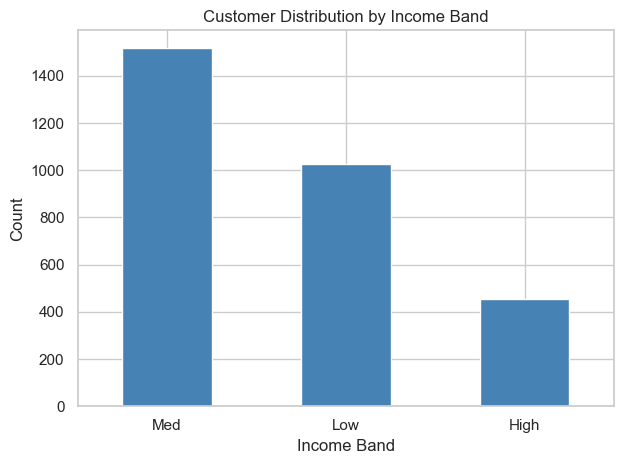

In [22]:
# Visualize the distribution of income bands
df['Income Band'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Customer Distribution by Income Band')
plt.xlabel('Income Band')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Categorical Columns — Value Counts

Before plotting, we examine the unique value distribution for each categorical column to understand class balance and potential data quality issues.

In [23]:
categorical_cols = df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns

# Print value counts for each categorical column
for col in categorical_cols:
  print(f"Value Counts for '{col}': ")
  display(df[col].value_counts())

Value Counts for 'BRId': 


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64

Value Counts for 'GenderId': 


GenderId
2    1512
1    1488
Name: count, dtype: int64

Value Counts for 'IAId': 


...

Properties Owned
2    777
1    776
3    742
0    705
Name: count, dtype: int64

Value Counts for 'Risk Weighting': 


Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64

Value Counts for 'Income Band': 


Income Band
Med     1517
Low     1027
High     456
Name: count, dtype: int64

## 6. Univariate Analysis - Categorical Variables

Count plots for each categorical column help us understand the individual distribution of each variable in isolation.

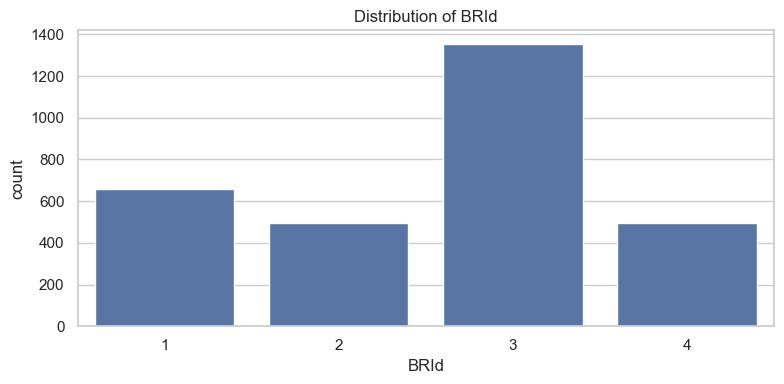

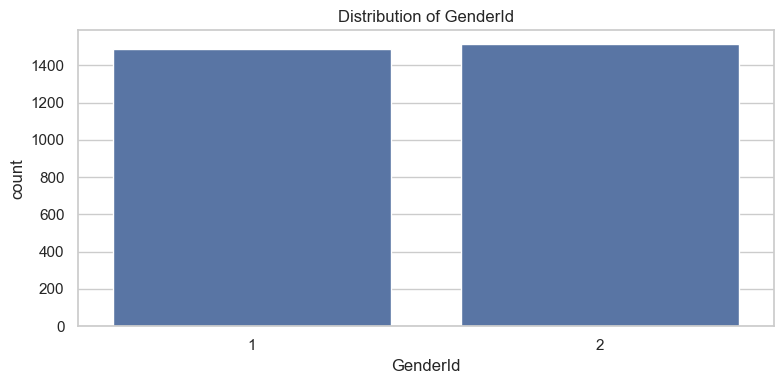

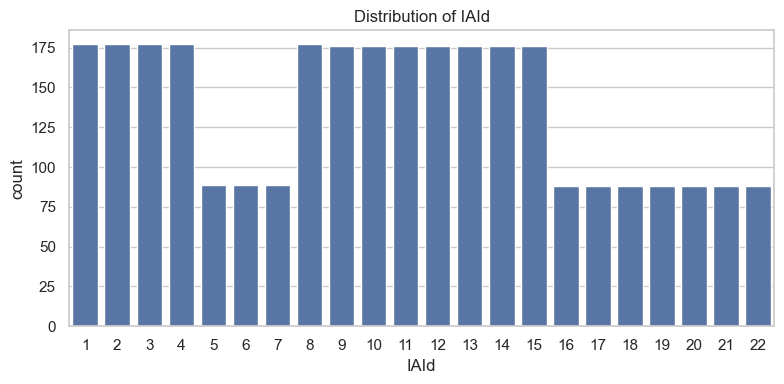

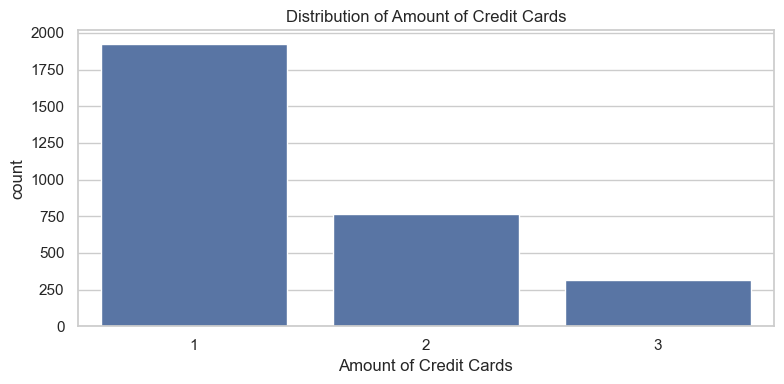

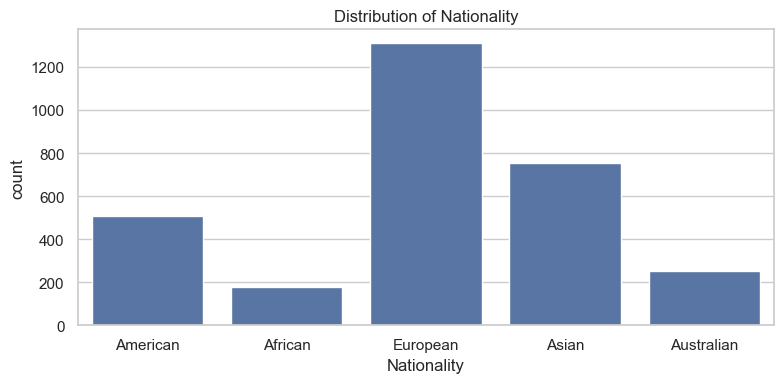

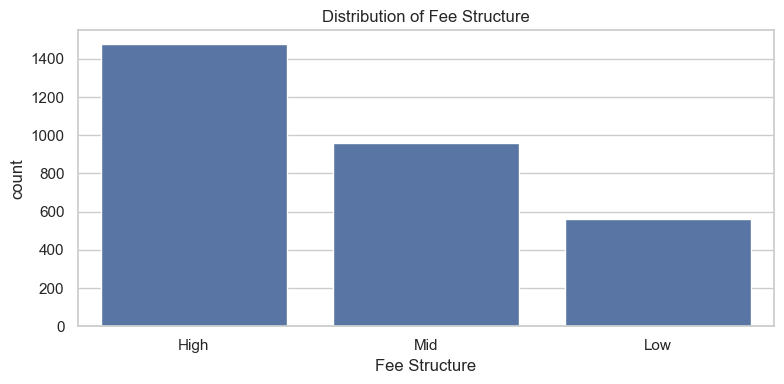

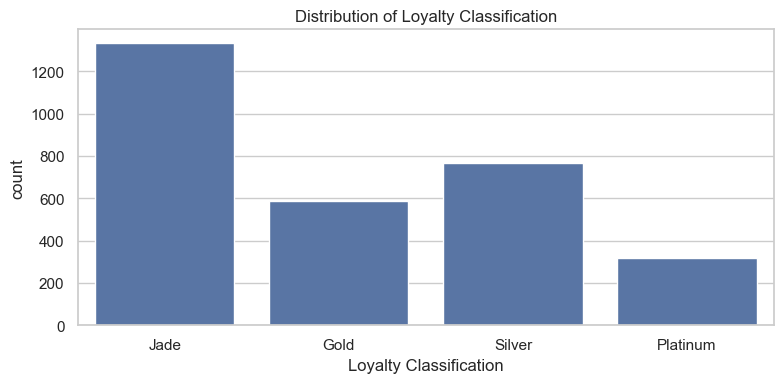

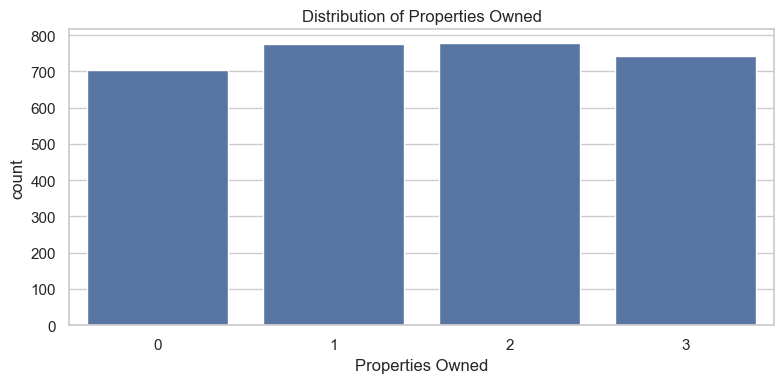

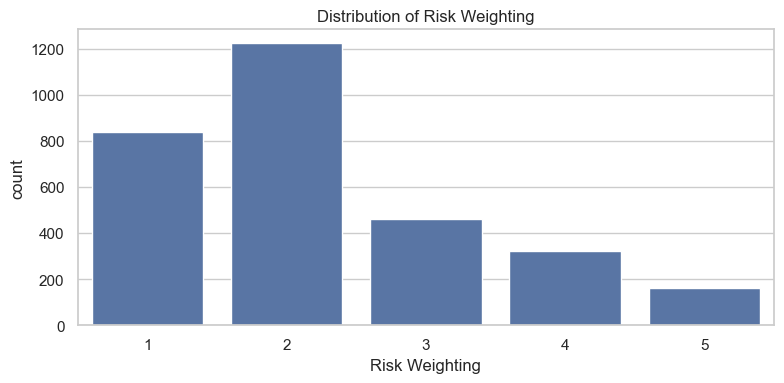

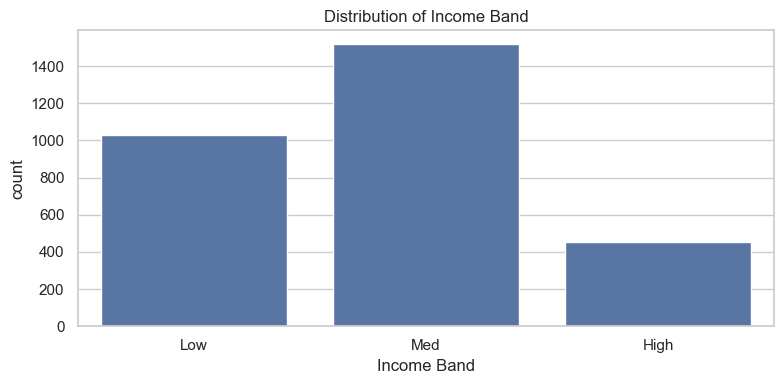

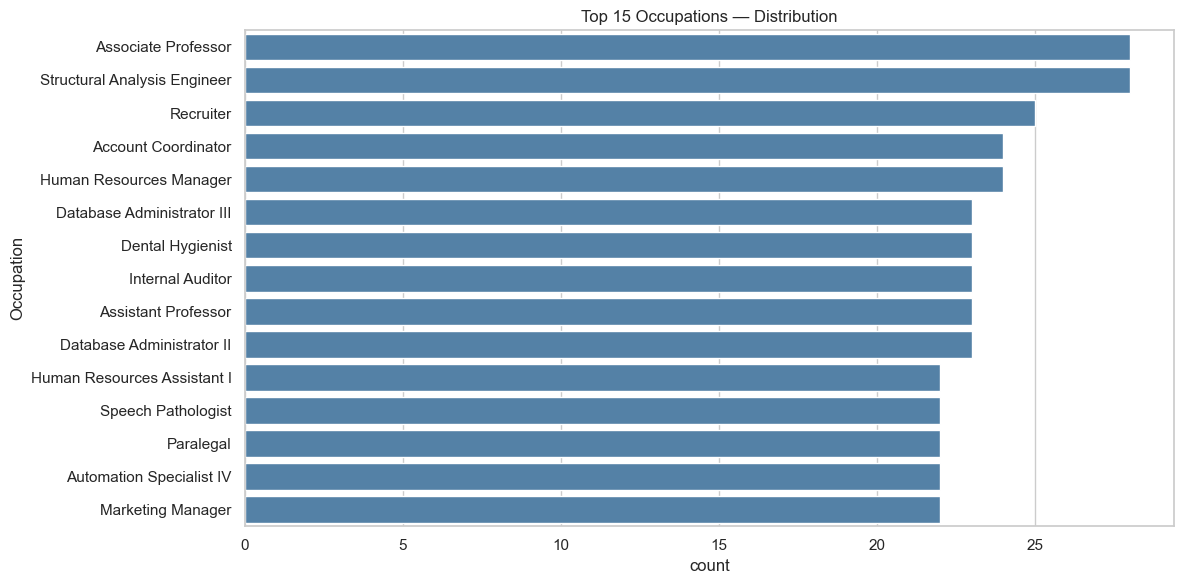

In [32]:
# Univariate Analysis — skipping Occupation (handled separately below)
for i, predictor in enumerate(categorical_cols):
    if predictor == 'Occupation':
        continue
    plt.figure(i, figsize=(8, 4))
    sns.countplot(data=df, x=predictor)
    plt.title(f'Distribution of {predictor}')
    plt.xticks()
    plt.tight_layout()
    plt.show()

# Occupation plotted separately due to high cardinality (195 unique values)
# Using Top 15 with horizontal bars for readability
top_occupations = df['Occupation'].value_counts().head(15).index
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['Occupation'].isin(top_occupations)], y='Occupation', order=top_occupations, color='steelblue')
plt.title('Top 15 Occupations — Distribution')
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Categorical vs. Nationality

Here we break down each categorical variable by `Nationality` to identify if certain customer groups show different behavioral or financial patterns.

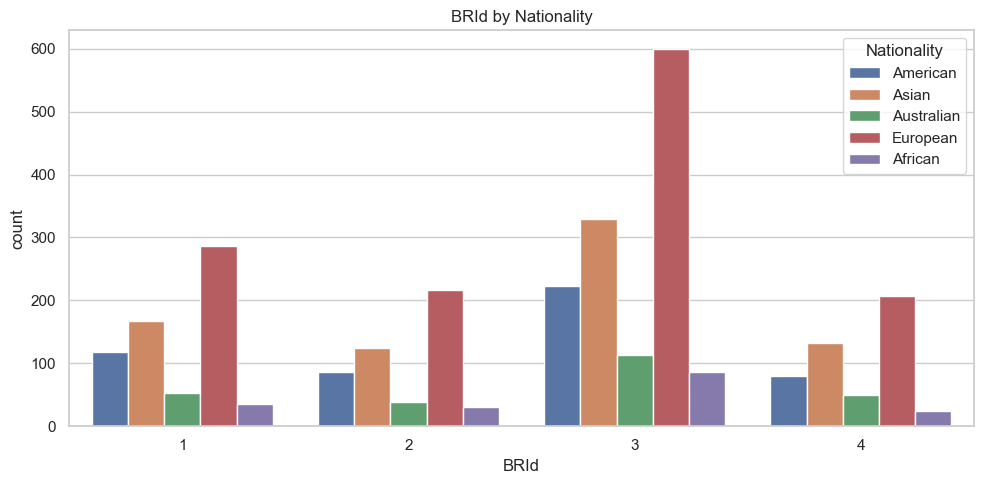

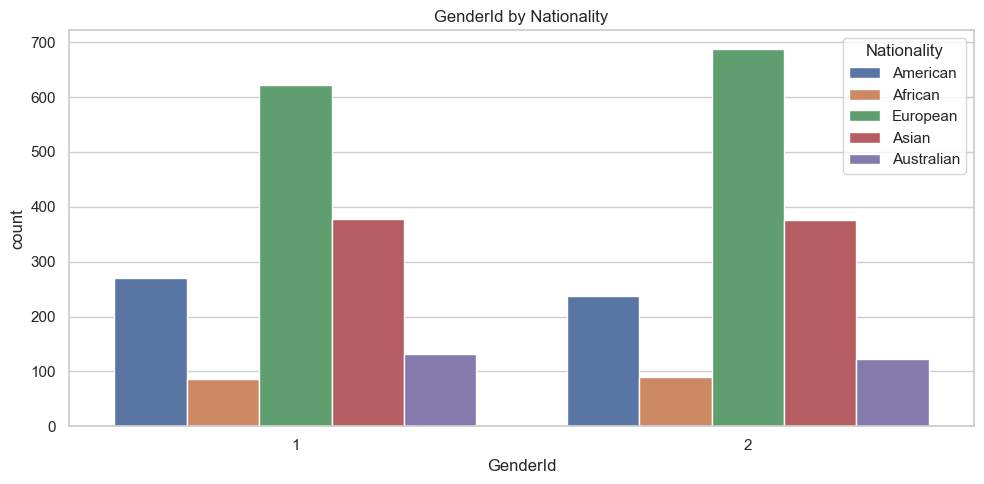

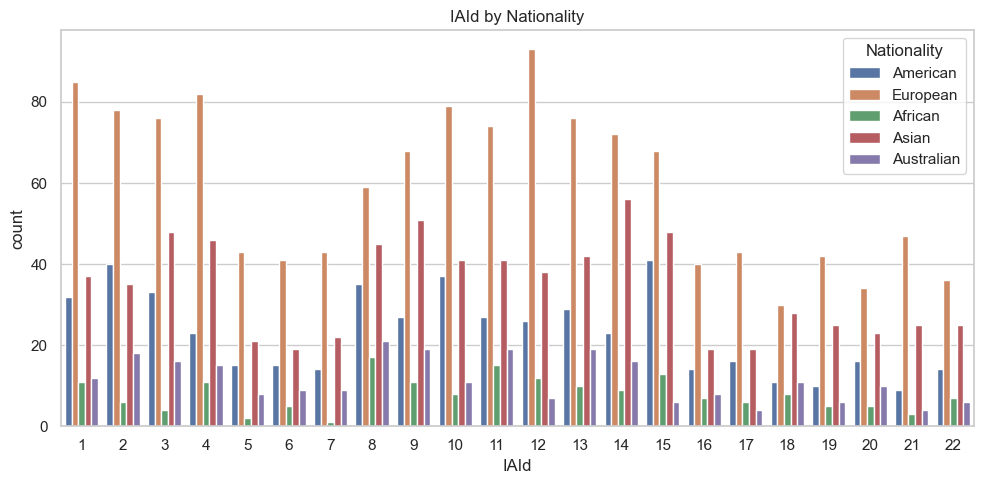

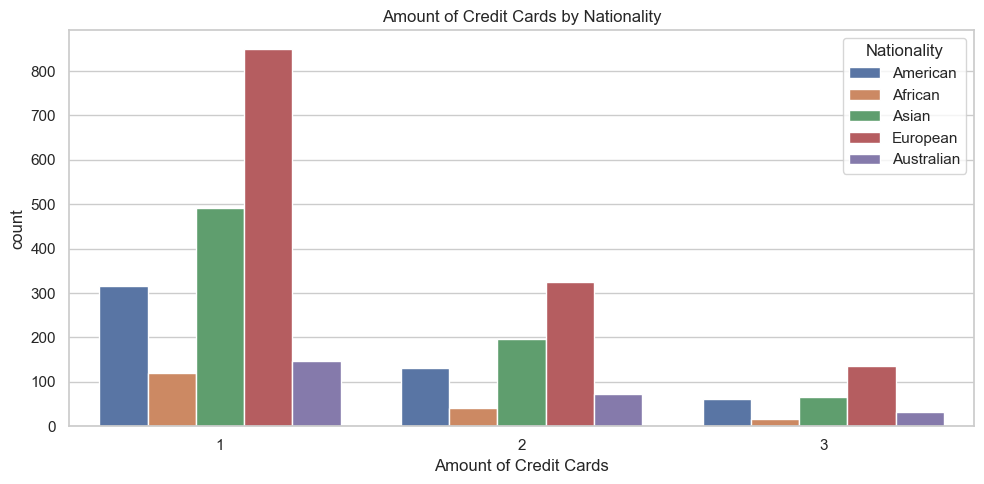

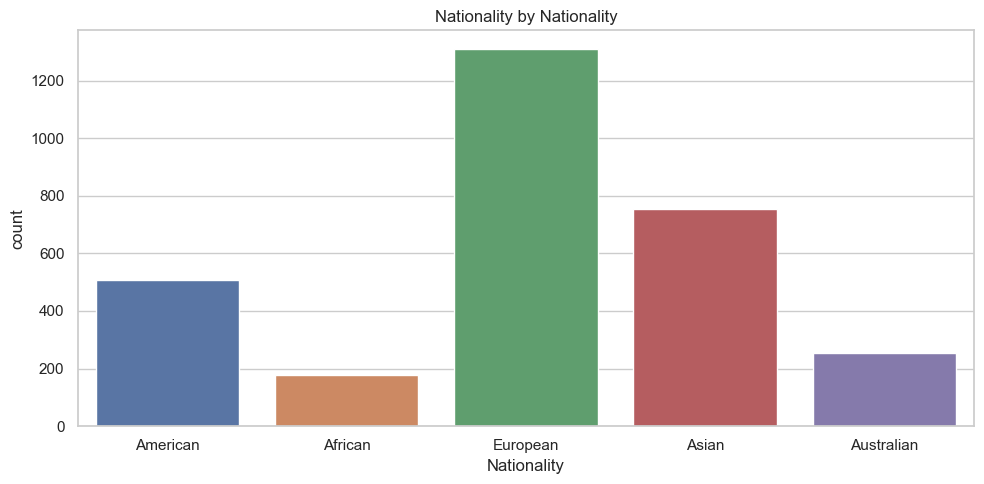

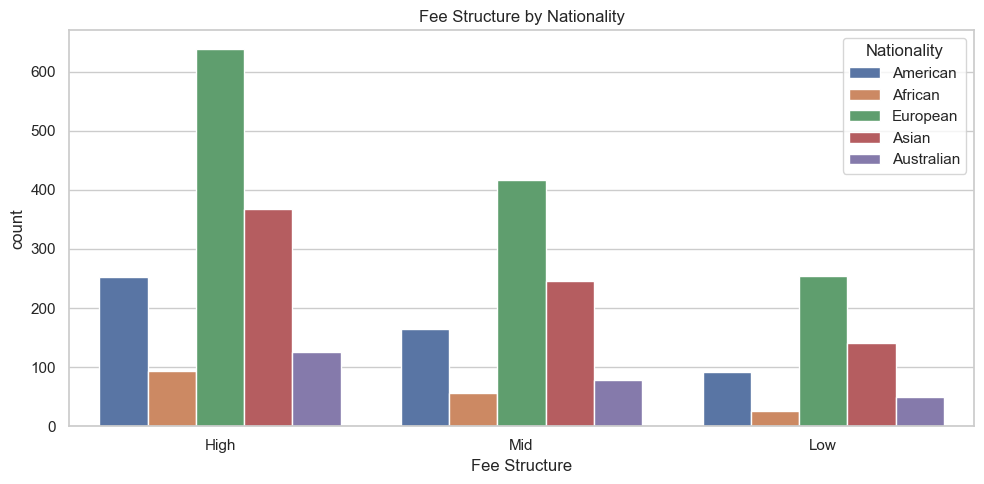

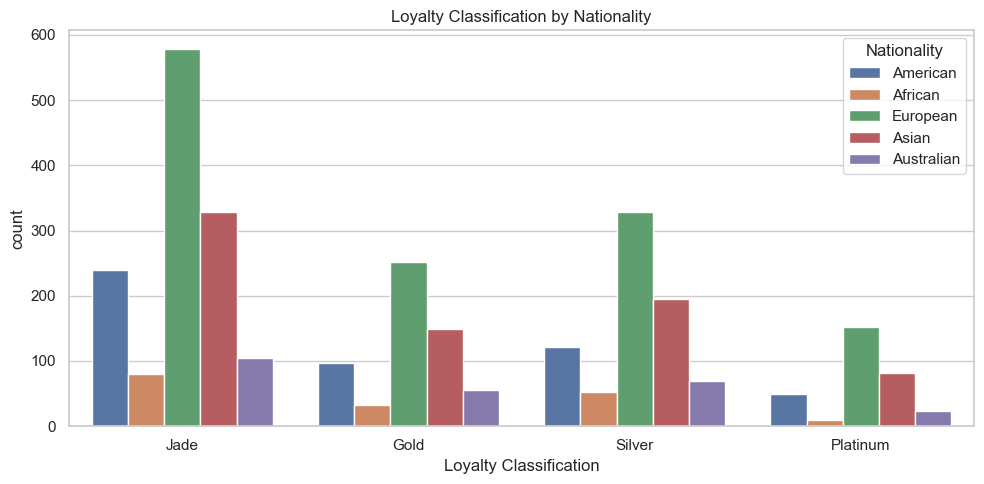

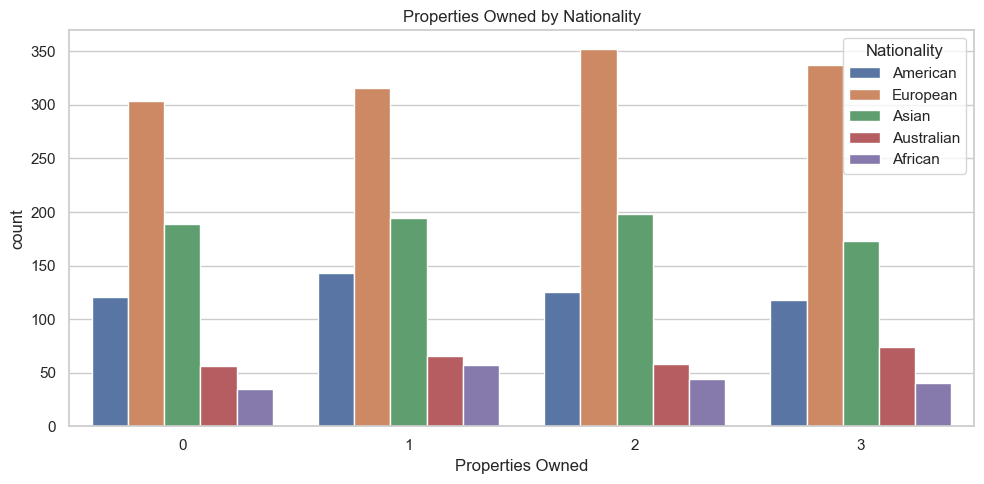

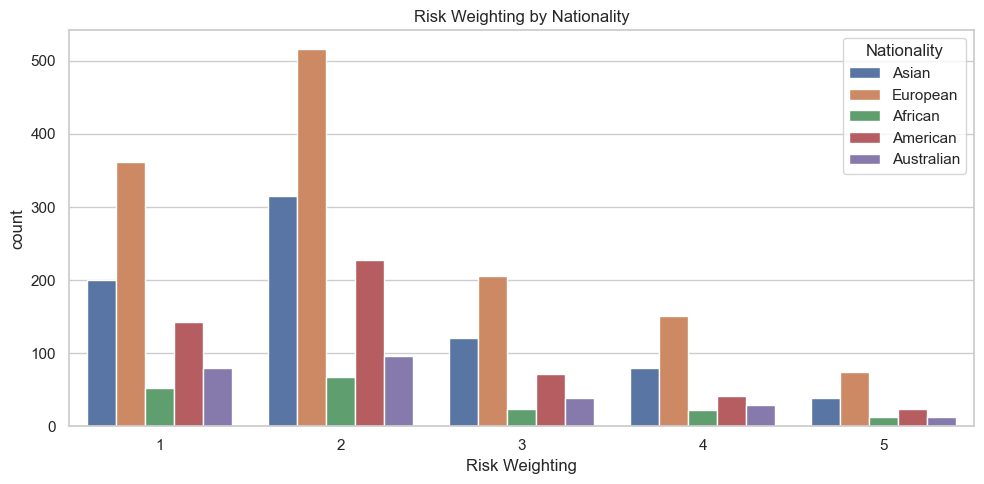

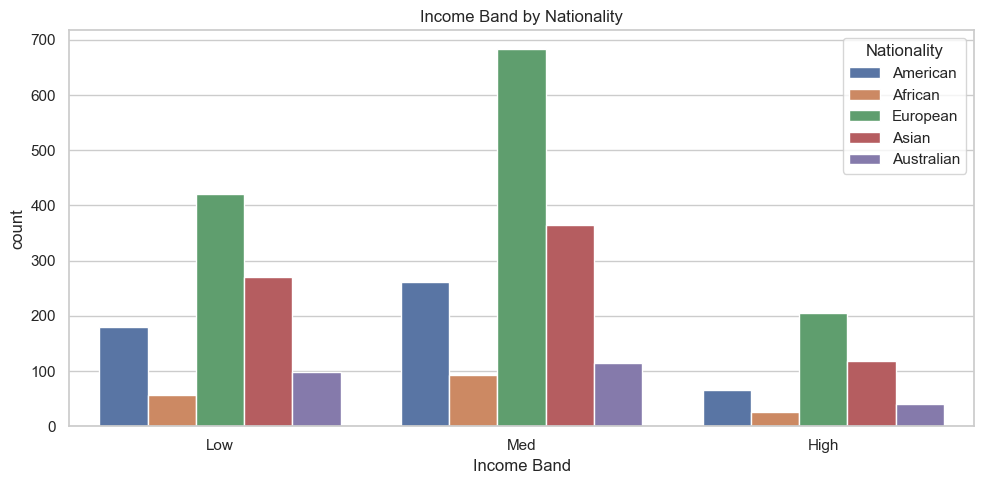

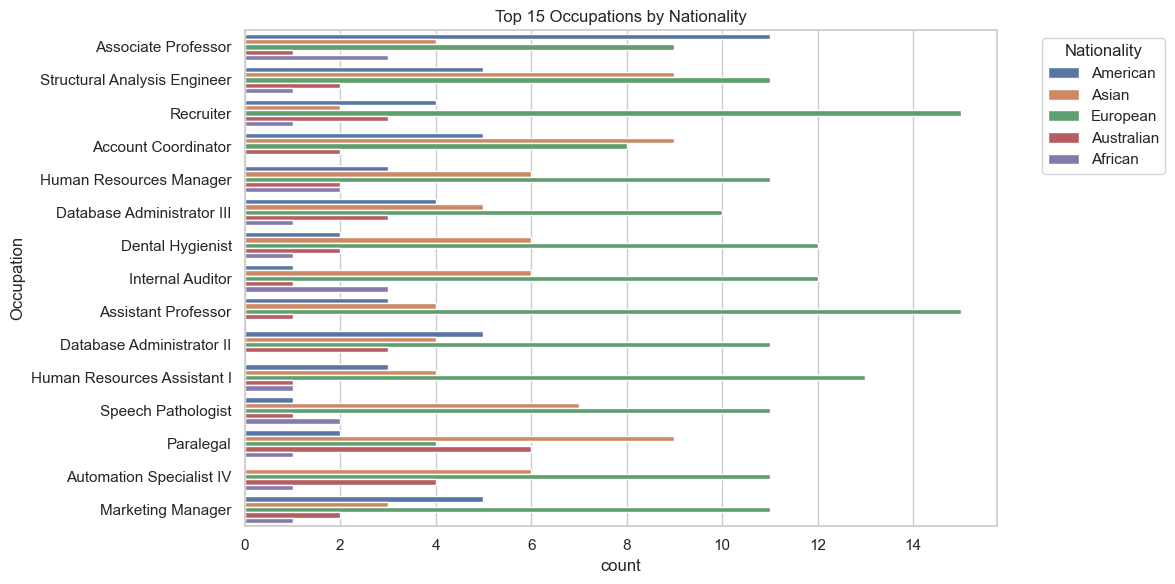

In [33]:
# Bivariate Analysis — skipping Occupation (handled separately below)
for i, predictor in enumerate(categorical_cols):
    if predictor == 'Occupation':
        continue
    plt.figure(i, figsize=(10, 5))
    sns.countplot(data=df, x=predictor, hue='Nationality')
    plt.title(f'{predictor} by Nationality')
    plt.xticks()
    plt.tight_layout()
    plt.show()

# Occupation by Nationality — Top 15 only, horizontal bars
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['Occupation'].isin(top_occupations)], y='Occupation', hue='Nationality', order=top_occupations)
plt.title('Top 15 Occupations by Nationality')
plt.legend(title='Nationality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

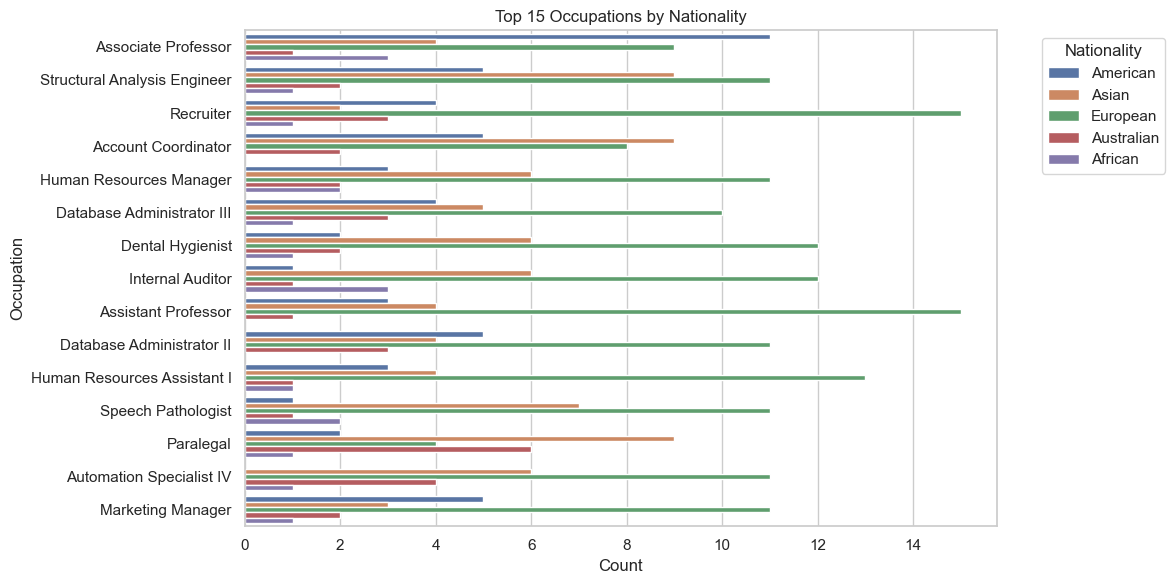

In [27]:
top_occupations = df['Occupation'].value_counts().head(15).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df[df['Occupation'].isin(top_occupations)],
    y='Occupation',          # Horizontal bars — much more readable for text labels
    hue='Nationality',
    order=top_occupations
)
plt.title('Top 15 Occupations by Nationality')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.legend(title='Nationality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Numerical Analysis — Financial Variables

We now examine the distribution of key financial columns using histograms with KDE (Kernel Density Estimation) to understand the shape, skewness, and spread of each variable.

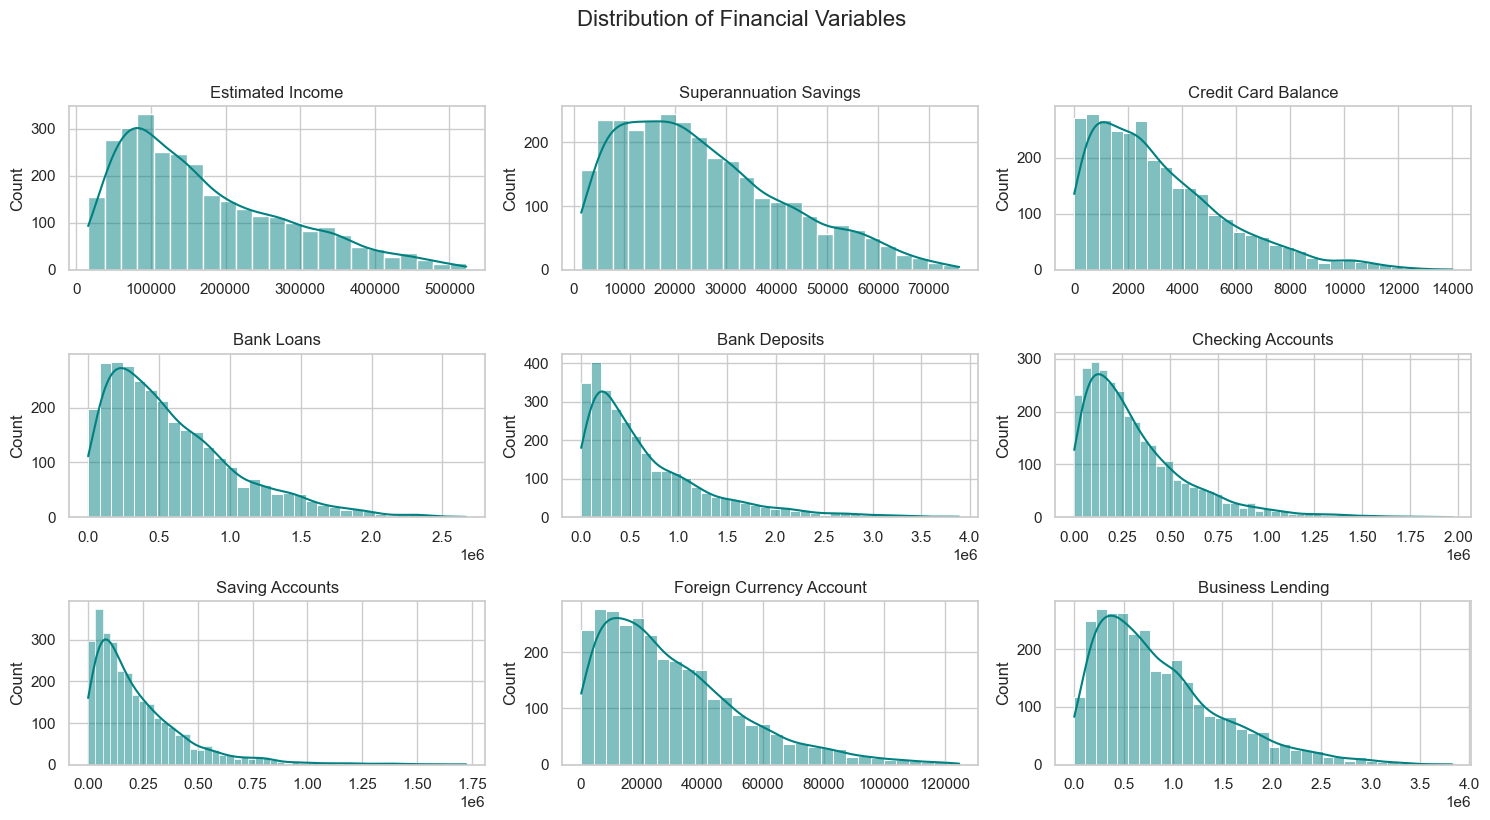

In [34]:
numerical_cols = [
    'Estimated Income', 'Superannuation Savings', 'Credit Card Balance',
    'Bank Loans', 'Bank Deposits', 'Checking Accounts',
    'Saving Accounts', 'Foreign Currency Account', 'Business Lending'
]

# Subplot grid for all financial variables — helps spot skewness & outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(col)
    plt.xlabel('')
plt.suptitle('Distribution of Financial Variables', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

A correlation matrix reveals **linear relationships** between all numerical financial columns. Strong positive correlations suggest customers who are financially active in one area tend to be active in others as well.

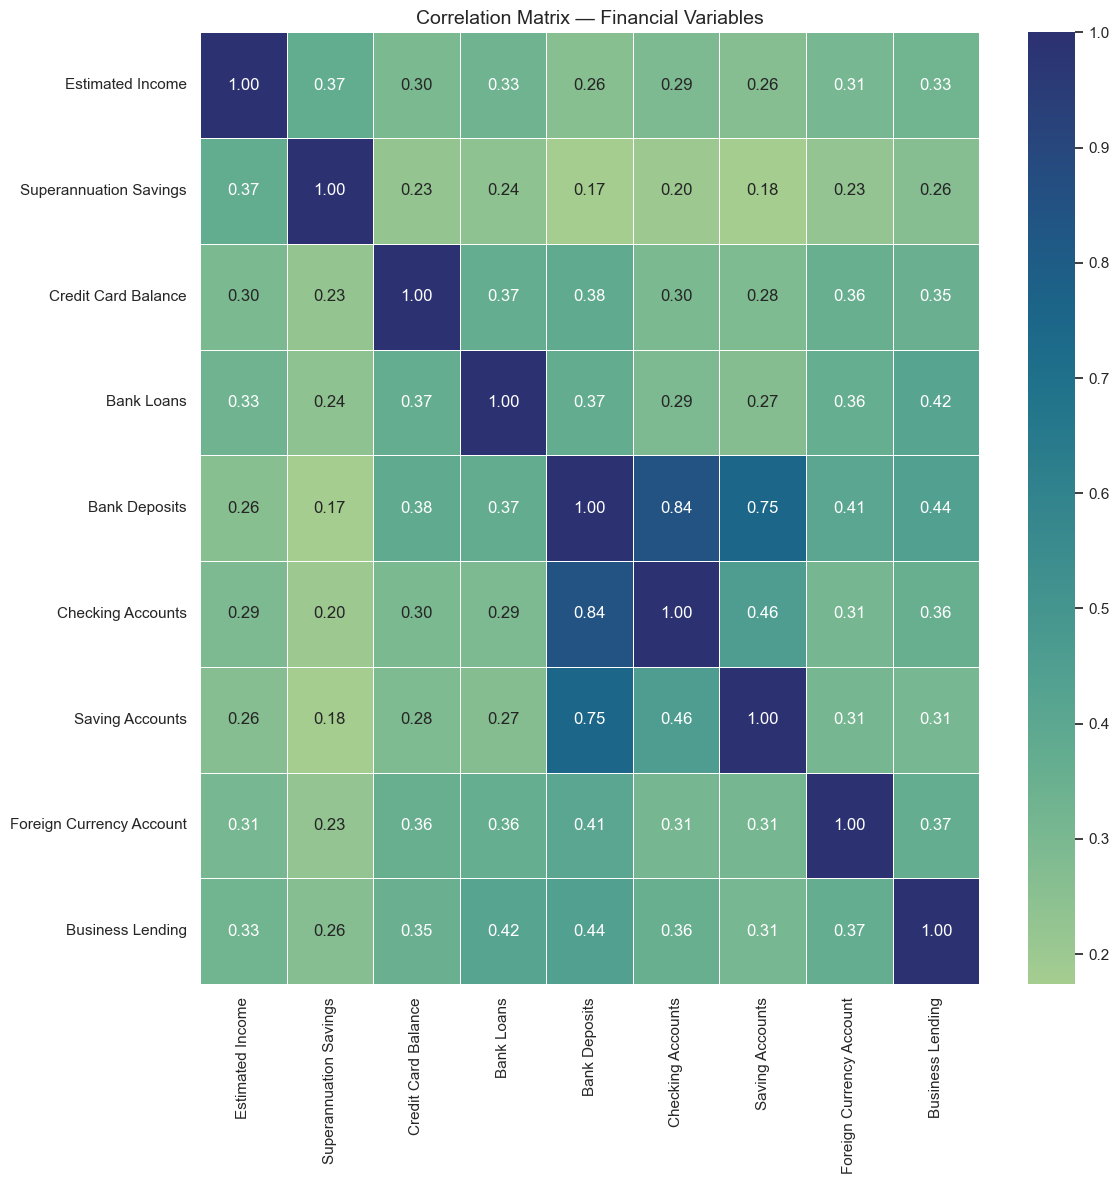

In [35]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

correlation_matrix = df[numerical_cols].corr()

# Heatmap with annotations — values close to 1 or -1 indicate strong relationships
plt.figure(figsize=(12, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='crest',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix — Financial Variables', fontsize=14)
plt.tight_layout()
plt.show()

## Summary of findings
1. Customer ages range from 17–75; majority are older, with 75% above 69 years
2. Most customers fall in the Medium income band
3. Bank Deposits show strong positive correlation with Checking Accounts, Saving Accounts.

### Next Step

- Build an interactive dashboard (Power BI) using these insights as the guiding framework